In [14]:
import torch 
from torch import nn
import matplotlib.pyplot as plt


In [15]:
weight = 0.7
bias = 0.3
x = torch.arange(0,10,0.02).unsqueeze(dim =1)
y = weight*x + bias
x[:10] , y[:10] 

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [38]:
train_split = int(0.8* len(x))
x_test = x[train_split:]
x_train = x[:train_split]
y_test = y[train_split:]
y_train = y[:train_split]
len(x_train), len(x_test)

(400, 100)

In [39]:
class linear_regression_model(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, dtype = torch.float, requires_grad = True))
        self.bias = nn.Parameter(torch.randn(1, dtype = torch.float, requires_grad = True))
    def forward(self, x:torch.Tensor) -> torch.tensor:
        return self.weights * x + self.bias

In [40]:
torch.manual_seed(42)
model0 = linear_regression_model()
list(model0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [41]:
with torch.inference_mode():
    y_preds = model0(x_test)


In [42]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params = model0.parameters(), lr = 0.02)

In [46]:
epochs = 100
test_loss_values =[]
train_loss_values =[]
epoch_count =[]
for epoch in range(epochs):
    
    #train
    model0.train()
    y_pred = model0(x_train)
    loss = loss_fn(y_pred,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #evaluate
    model0.eval()
    with torch.inference_mode():
        test_pred = model0(x_test)
        test_loss = loss_fn(test_pred, y_test)
        if epoch%10==0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"{epoch}| MAE TRAIN LOSS: {train_loss_values} | MAE TEST {test_loss_values}")

0| MAE TRAIN LOSS: [array(0.08461996, dtype=float32)] | MAE TEST [array(0.5724189, dtype=float32)]
10| MAE TRAIN LOSS: [array(0.08461996, dtype=float32), array(0.08411995, dtype=float32)] | MAE TEST [array(0.5724189, dtype=float32), array(0.572919, dtype=float32)]
20| MAE TRAIN LOSS: [array(0.08461996, dtype=float32), array(0.08411995, dtype=float32), array(0.08411995, dtype=float32)] | MAE TEST [array(0.5724189, dtype=float32), array(0.572919, dtype=float32), array(0.572919, dtype=float32)]
30| MAE TRAIN LOSS: [array(0.08461996, dtype=float32), array(0.08411995, dtype=float32), array(0.08411995, dtype=float32), array(0.08411995, dtype=float32)] | MAE TEST [array(0.5724189, dtype=float32), array(0.572919, dtype=float32), array(0.572919, dtype=float32), array(0.572919, dtype=float32)]
40| MAE TRAIN LOSS: [array(0.08461996, dtype=float32), array(0.08411995, dtype=float32), array(0.08411995, dtype=float32), array(0.08411995, dtype=float32), array(0.08411995, dtype=float32)] | MAE TEST [ar

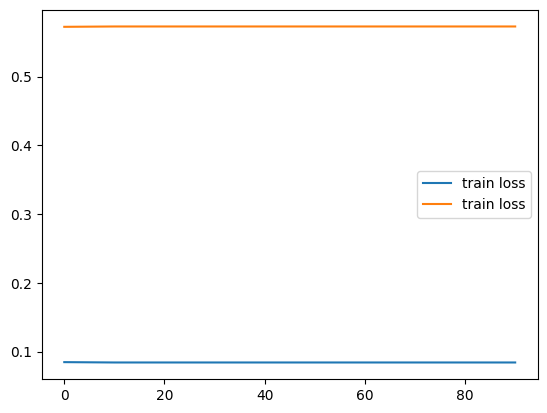

In [47]:
plt.plot(epoch_count, train_loss_values, label ="train loss")
plt.plot(epoch_count, test_loss_values, label ="train loss")
plt.legend()

In [48]:
print(list(model0.parameters()))

[Parameter containing:
tensor([0.6839], requires_grad=True), Parameter containing:
tensor([0.2800], requires_grad=True)]
